# Fuzzy - Detekcja prawdopodobieństwa wypadku drogowego

#### Opracowanie: Kacper Książek, 417564
#### 25.05.2025

---


### 1. 📦 Importowanie bibliotek


In [102]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

### 2. 🛣️ Definiowanie zmiennych rozmytych

#### 2.1 Zmienna wejściowa: Prędkość pojazdu

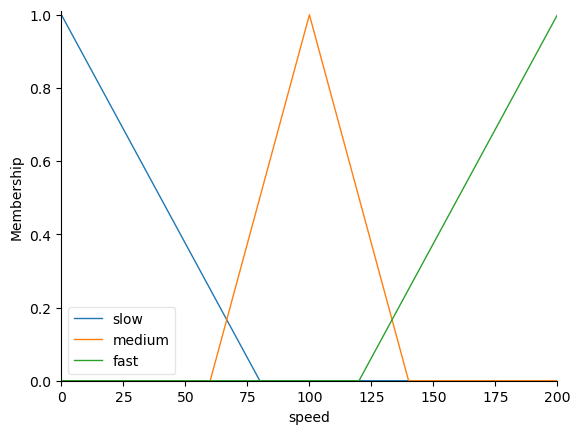

In [103]:
speed = ctrl.Antecedent(np.arange(0, 201, 1), 'speed')  # prędkość [0-200 km/h]
speed['slow'] = fuzz.trimf(speed.universe, [0, 0, 80])
speed['medium'] = fuzz.trimf(speed.universe, [60, 100, 140])
speed['fast'] = fuzz.trimf(speed.universe, [120, 200, 200])

speed.view()

#### 2.2 Zmienna wejściowa: Odległość do przeszkody

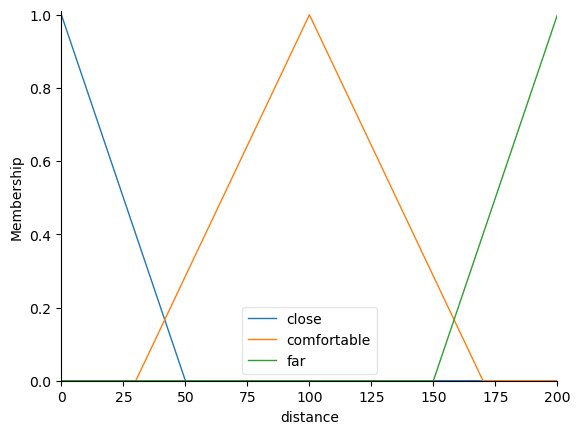

In [104]:
distance = ctrl.Antecedent(np.arange(0, 201, 1), 'distance')  # odległość [0-200 m]
distance['close'] = fuzz.trimf(distance.universe, [0, 0, 50])
distance['comfortable'] = fuzz.trimf(distance.universe, [30, 100, 170])
distance['far'] = fuzz.trimf(distance.universe, [150, 200, 200])

distance.view()

#### 2.3 Zmienna wyjściowa: Zagrożenie wypadkiem

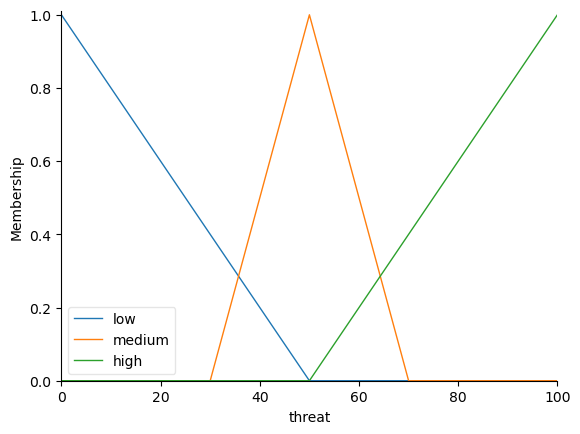

In [105]:
threat = ctrl.Consequent(np.arange(0, 101, 1), 'threat')  # zagrożenie [%]
threat['low'] = fuzz.trimf(threat.universe, [0, 0, 50])
threat['medium'] = fuzz.trimf(threat.universe, [30, 50, 70])
threat['high'] = fuzz.trimf(threat.universe, [50, 100, 100])

threat.defuzzify_method = "mom"

threat.view()

 ### 3. 🧠 System reguł rozmytych

In [106]:
threat_ctrl = ctrl.ControlSystem([
    ctrl.Rule(speed['fast'] & distance['close'], threat['high']),
    ctrl.Rule(speed['fast'] & distance['comfortable'], threat['high']),
    ctrl.Rule(speed['fast'] & distance['far'], threat['medium']),

    ctrl.Rule(speed['medium'] & distance['close'], threat['high']),
    ctrl.Rule(speed['medium'] & distance['comfortable'], threat['medium']),
    ctrl.Rule(speed['medium'] & distance['far'], threat['low']),

    ctrl.Rule(speed['slow'] & distance['close'], threat['medium']),
    ctrl.Rule(speed['slow'] & distance['comfortable'], threat['low']),
    ctrl.Rule(speed['slow'] & distance['far'], threat['low']),
])

threat_simulation = ctrl.ControlSystemSimulation(threat_ctrl)

### 4. 📊 Wizualizacja reguł

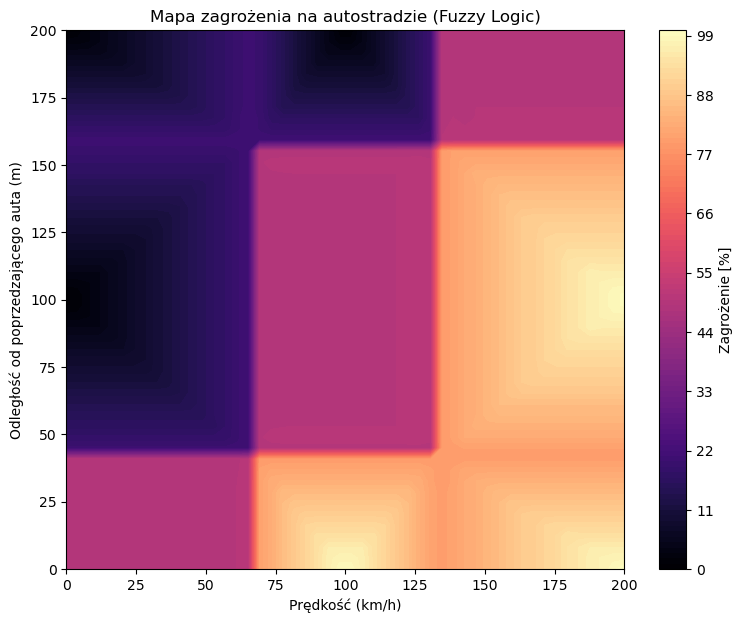

In [107]:
sim = ctrl.ControlSystemSimulation(threat_ctrl)

speed_values = np.linspace(0, 200, 50)
distance_values = np.linspace(0, 200, 50)

Z = np.zeros((len(distance_values), len(speed_values)))

for i, d in enumerate(distance_values):
    for j, s in enumerate(speed_values):
        sim.input['speed'] = s
        sim.input['distance'] = d
        sim.compute()
        Z[i, j] = sim.output['threat']

plt.figure(figsize=(9, 7))
cp = plt.contourf(speed_values, distance_values, Z, levels=100, cmap='magma')
cbar = plt.colorbar(cp)
cbar.set_label('Zagrożenie [%]')
plt.xlabel('Prędkość (km/h)')
plt.ylabel('Odległość od poprzedzającego auta (m)')
plt.title('Mapa zagrożenia na autostradzie (Fuzzy Logic)')
plt.gca()

plt.show()

### 5. 🧪 Testowanie algorytmu

In [108]:
samples = [
    {'speed': 40, 'distance': 150},
    {'speed': 60, 'distance': 80},
    {'speed': 90, 'distance': 50},
    {'speed': 120, 'distance': 20},
    {'speed': 180, 'distance': 100},
    {'speed': 200, 'distance': 1},
    {'speed': 0, 'distance': 200},
    {'speed': 150, 'distance': 300},
]

for index, s in enumerate(samples):
    threat_simulation.input['speed'] = s['speed']
    threat_simulation.input['distance'] = s['distance']
    threat_simulation.compute()

    threat = round(threat_simulation.output.get('threat'), 2)

    threat_category = '🟩 Niskie' if threat < 30 else '🟨 Umiarkowane' if threat < 70 else '🟥 WYSOKIE'

    print(f"Próbka {index + 1}:")
    print(f"- Parametry: Prędkość: {s['speed']} km/h, Odległość: {s['distance']} m")
    print(f"- Zagrożenie: {threat_category} ( szansa na wypadek: {threat}% )")
    print("\n")

Próbka 1:
- Parametry: Prędkość: 40 km/h, Odległość: 150 m
- Zagrożenie: 🟩 Niskie ( szansa na wypadek: 17.99% )


Próbka 2:
- Parametry: Prędkość: 60 km/h, Odległość: 80 m
- Zagrożenie: 🟩 Niskie ( szansa na wypadek: 18.99% )


Próbka 3:
- Parametry: Prędkość: 90 km/h, Odległość: 50 m
- Zagrożenie: 🟨 Umiarkowane ( szansa na wypadek: 49.52% )


Próbka 4:
- Parametry: Prędkość: 120 km/h, Odległość: 20 m
- Zagrożenie: 🟥 WYSOKIE ( szansa na wypadek: 87.5% )


Próbka 5:
- Parametry: Prędkość: 180 km/h, Odległość: 100 m
- Zagrożenie: 🟥 WYSOKIE ( szansa na wypadek: 93.54% )


Próbka 6:
- Parametry: Prędkość: 200 km/h, Odległość: 1 m
- Zagrożenie: 🟥 WYSOKIE ( szansa na wypadek: 99.5% )


Próbka 7:
- Parametry: Prędkość: 0 km/h, Odległość: 200 m
- Zagrożenie: 🟩 Niskie ( szansa na wypadek: 0.0% )


Próbka 8:
- Parametry: Prędkość: 150 km/h, Odległość: 300 m
- Zagrożenie: 🟨 Umiarkowane ( szansa na wypadek: 50.0% )


